# Basic tutorial of UNsim

In this notebook, the basic feature of UNsim is demonstrated. 

This tutorial is currently under development. The current explanation content remains minimal. For the basic usage of UNsim, the tutorial of [UXsim](https://github.com/toruseo/UXsim) (a mesoscopic traffic flow simulator with very similar features and syntax) might be useful.

## Python-based forward simulation

The most basic feature of UNsim is a macroscopic traffic simulation in Python.

### Simple Y-shaped network

First, import the necessary modules.

In [1]:
from unsim import World
import matplotlib.pyplot as plt

Define the main simulation environment `World`. The most important args are `tmax` (simulation duration) and `deltat` (time step width).

In [2]:
# Units are standardized to seconds (s) and meters (m)
W = World(
    name="merge", deltat=5, tmax=1200,    
    print_mode=1, save_mode=0, show_mode=1,
)


Then, setup the network by defining `Node` and `Link`. The `Node`'s `x` and `y` coordinates are for visualization only. The actual network size is determined by `length` of `Link.

In [3]:
W.addNode("orig1", x=0, y=0)
W.addNode("orig2", x=0, y=2)
W.addNode("merge", x=1, y=1)
W.addNode("dest", x=2, y=1)
W.addLink("link1", "orig1", "merge", length=1000, free_flow_speed=20, capacity=0.8, merge_priority=1)
W.addLink("link2", "orig2", "merge", length=1000, free_flow_speed=20, capacity=0.8, merge_priority=1)
W.addLink("link3", "merge", "dest", length=1000, free_flow_speed=20, capacity=0.8)


<Link 'link3'>

And add the traffic demand. `flow` means demand flow-rate in vehicle per second unit.

In [4]:
W.adddemand("orig1", "dest", t_start=0, t_end=1000, flow=0.45)
W.adddemand("orig2", "dest", t_start=400, t_end=1000, flow=0.6)

Now we have set up a Y-shaped merging network.
The capacity of the downstream link is 0.8 veh/s, and the total demand is 0.45 for until 400 s and 1.05 s after 400 s. 
We can expect that congestion will happen at the merging node some time after 400 s.

The simulation can be executed by

In [5]:
W.exec_simulation()

 Simulation completed. merge


Let's see some statistics and visualizations.


  Simulation Results:
    Total trips:     810.0
    Completed trips: 740.0
    Total travel time: 136825.0 s
    Avg travel time: 184.9 s
    Avg delay:       84.9 s


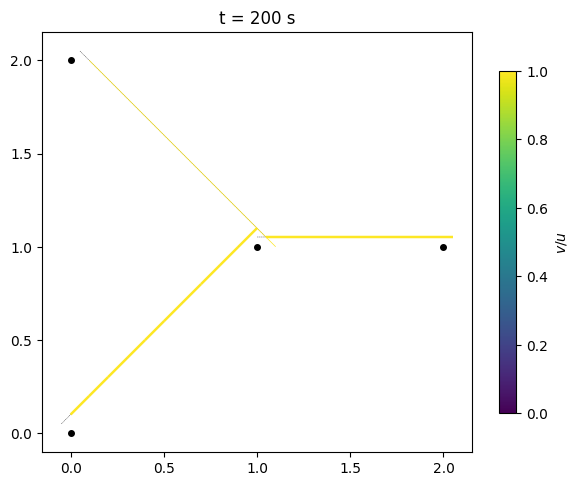

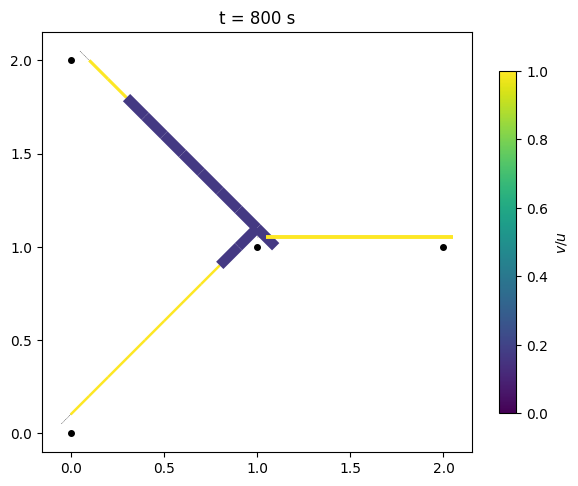

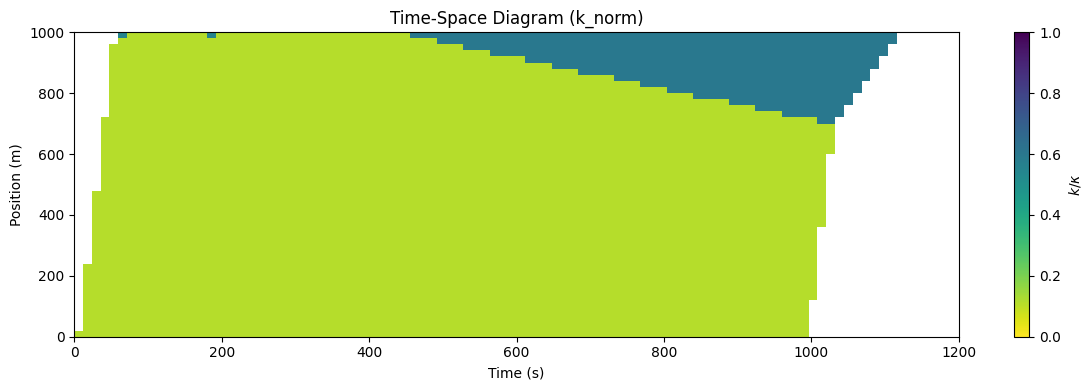

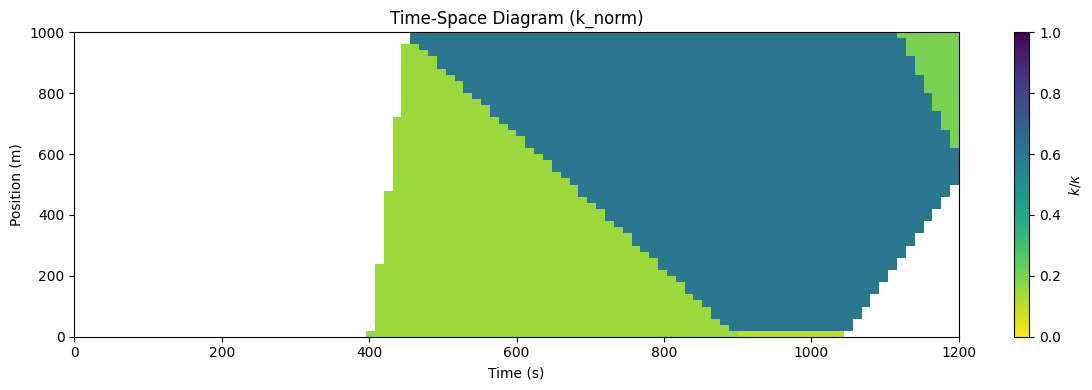

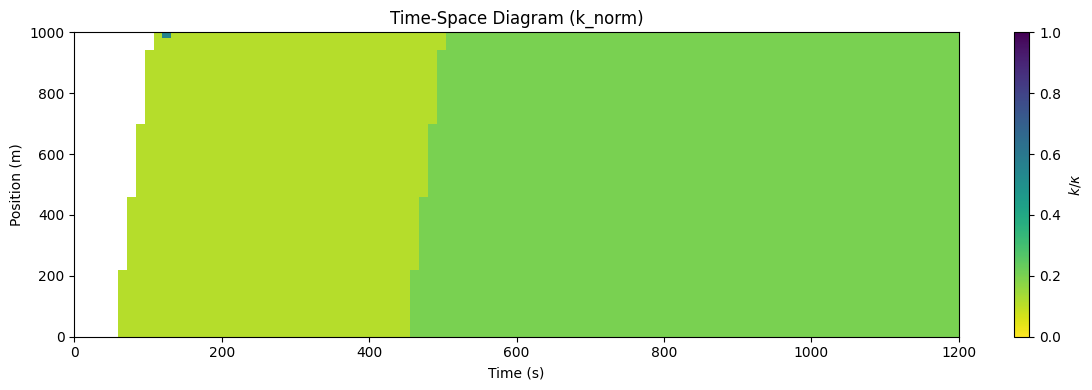

In [6]:
#stats
W.analyzer.print_simple_stats()

#network plots
W.analyzer.network(t=200)
W.analyzer.network(t=800)

#link time-space diagrams
W.analyzer.time_space_diagram(mode="k_norm", links="link1")
W.analyzer.time_space_diagram(mode="k_norm", links="link2")
W.analyzer.time_space_diagram(mode="k_norm", links="link3")

plt.show()

You can see the congestion as expected.

### Large-scale network with program-based generation

to be added

## JAX-based acceleration

By using JAX, simulation Worlds of UNsim defined by Python codes can be compiled to JAX object that can run very fast using CPU or GPU and be differentiated by Automatic Differentiation.

Let's define the same scenario to the previous Y network. Note that this scenario is very small and not suitable for JAX-based high performance computation. The compilation overhead becomes significant enough to actually slow down the process. But since this is a tutorial, let's proceed.

In [7]:
W = World(
    name="merge", deltat=5, tmax=1200,    
    print_mode=1, save_mode=0, show_mode=1,
)
W.addNode("orig1", x=0, y=0)
W.addNode("orig2", x=0, y=2)
W.addNode("merge", x=1, y=1)
W.addNode("dest", x=2, y=1)
W.addLink("link1", "orig1", "merge", length=1000, free_flow_speed=20, capacity=0.8, merge_priority=1)
W.addLink("link2", "orig2", "merge", length=1000, free_flow_speed=20, capacity=0.8, merge_priority=1)
W.addLink("link3", "merge", "dest", length=1000, free_flow_speed=20, capacity=0.8)
W.adddemand("orig1", "dest", t_start=0, t_end=1000, flow=0.45)
W.adddemand("orig2", "dest", t_start=400, t_end=1000, flow=0.6)

Now we import the necessary module, convert the World to JAX object, and run JAX-based simulation.

For now, this feature is not very human-friendly. Some improvements are planned.

In [8]:
from unsim.unsim_diff import *

params, config = world_to_jax(W)
state = simulate(params, config)


You can access the results like this.

In [9]:
ttt = total_travel_time(state, config)
print(f"Total travel time: {ttt:.1f} s")

Total travel time: 136824.9 s


## Automatic Differentiation

The great feature of JAX is the Automatic Differentiation (AD). 
By using AD, we can compute gradient of the simulation output with respect to any input parameter.

Let's reuse the previous Y scenario again.

In [10]:
from unsim import World
from unsim.unsim_diff import *

W = World(
    name="merge", deltat=5, tmax=1200,    
    print_mode=1, save_mode=0, show_mode=1,
)
W.addNode("orig1", x=0, y=0)
W.addNode("orig2", x=0, y=2)
W.addNode("merge", x=1, y=1)
W.addNode("dest", x=2, y=1)
W.addLink("link1", "orig1", "merge", length=1000, free_flow_speed=20, capacity=0.8, merge_priority=1)
W.addLink("link2", "orig2", "merge", length=1000, free_flow_speed=20, capacity=0.8, merge_priority=1)
W.addLink("link3", "merge", "dest", length=1000, free_flow_speed=20, capacity=0.8)
W.adddemand("orig1", "dest", t_start=0, t_end=1000, flow=0.45)
W.adddemand("orig2", "dest", t_start=400, t_end=1000, flow=0.6)

params, config = world_to_jax(W)
state = simulate(params, config)

ttt = total_travel_time(state, config)
print(f"Total travel time: {ttt:.1f} s")


Total travel time: 136824.9 s


By using this `ttt` object, you can compute gradient of $TTT$ (total travel time) with respect to the input parameters contained in `params`.

For example, lets compute $\partial TTT/\partial u_l$ where $u_l$ denotes free-flow speed of link $l$. It is expected that these values should be negative, as increasing the maximum speed should decrease the total travel time.

In [11]:
def ttt_wrt_u(u):
    p = params._replace(u=u)
    s = simulate(p, config)
    return total_travel_time(s, config)

grad_u = jax.grad(ttt_wrt_u)(params.u)

print(f"\nGradient of TTT w.r.t. free-flow speed:")
for i, link in enumerate(W.LINKS):
    print(f"  {link.name}: {float(grad_u[i]):.2f}")


Gradient of TTT w.r.t. free-flow speed:
  link1: -1226.95
  link2: -543.75
  link3: -1847.19


We got an expected result. 
Furthermore, notice that $\partial TTT/\partial u_3$ has largest absolute value. 
This indicates that the free-flow speed of link3 has the largest impact to TTT; this is also reasonable, as all traffic must use link3 after the merge.

FYI, the `param` contains the following elements. These parameters can be used to differentiate output variables. On the other hand, an output variable to be differentiated should be constructed from `unsim_diff`'s function. These definition can be tricky.

In [12]:
[param for param in params.__dir__() if not param.startswith("_")]

['u',
 'kappa',
 'q_star',
 'capacity_out',
 'capacity_in',
 'flow_capacity',
 'absorption_ratio',
 'diverge_ratios',
 'merge_priority',
 'demand_rate',
 'turning_fractions',
 'od_demand_rate',
 'toll',
 'route_bias',
 'index',
 'count']